In [1]:
import snapatac2 as snap
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron'
snap.__version__

'2.6.4'

## data

In [2]:
data = snap.read_dataset("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads")
# data.obs[:].to_pandas()
data

AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'
    obsm: 'fragment_paired'

In [3]:
adata = data.to_adata()

In [4]:
data.close()

In [5]:
adata

AnnData object with n_obs × n_vars = 109782 × 606219
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'
    obsm: 'fragment_paired'

In [6]:
# annotation
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/Neuron/neuron_lineage.csv", index_col=0)
anno

,barcode2,sample2,celltype
AAACAGCCATCGTTCT-1-0,AAACAGCCATCGTTCT-1,GW6,NPC
AAACCGAAGACCATAC-1-0,AAACCGAAGACCATAC-1,GW6,NPC
AAACCGAAGGTCCACA-1-0,AAACCGAAGGTCCACA-1,GW6,NPC
AAACCGAAGTCATGCG-1-0,AAACCGAAGTCATGCG-1,GW6,NPC
AAACCGGCAAATTGCT-1-0,AAACCGGCAAATTGCT-1,GW6,NPC
...,...,...,...
TTTGTGAAGCGCCTAA-1-7,TTTGTGAAGCGCCTAA-1,GW20,OPC
TTTGTGGCAAGATTCT-1-7,TTTGTGGCAAGATTCT-1,GW20,OPC
TTTGTGGCAAGTCGCT-1-7,TTTGTGGCAAGTCGCT-1,GW20,dIPC
TTTGTGGCACGTAATT-1-7,TTTGTGGCACGTAATT-1,GW20,OPC


In [7]:
adata = adata[adata.obs.index.isin(anno.index)]
adata.obs = adata.obs.join(anno)

In [8]:
adata.obs = adata.obs[['sample2', 'barcode2', 'celltype']]

In [9]:
adata.obs['celltype'] = adata.obs['celltype'].astype(str)
# sample2 为 GW12 且 celltype 为 dIPC -> 改为 dIPC_switching
mask_switching = (adata.obs['celltype'] == 'dIPC') & (adata.obs['sample2'] == 'GW12')
adata.obs.loc[mask_switching, 'celltype'] = 'dIPC_switching'

# sample2 为 GW16, GW17, GW20 且 celltype 为 dIPC -> 改为 dIPC_switched
target_samples = ['GW16', 'GW17', 'GW20']
mask_switched = (adata.obs['celltype'] == 'dIPC') & (adata.obs['sample2'].isin(target_samples))
adata.obs.loc[mask_switched, 'celltype'] = 'dIPC_switched'

adata.obs['celltype'] = adata.obs['celltype'].astype('category')

In [10]:
adata.obs['sample2'].value_counts()

sample2
GW7     2350
GW16    2230
GW20    1162
GW17    1086
GW10     968
GW9      845
GW12     822
GW6      785
Name: count, dtype: int64

# Calculate spectral

In [11]:
snap.pp.select_features(adata, n_features=250000)
snap.tl.spectral(adata)
snap.tl.umap(adata)

2025-12-23 20:51:24 - INFO - Selected 250000 features.
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


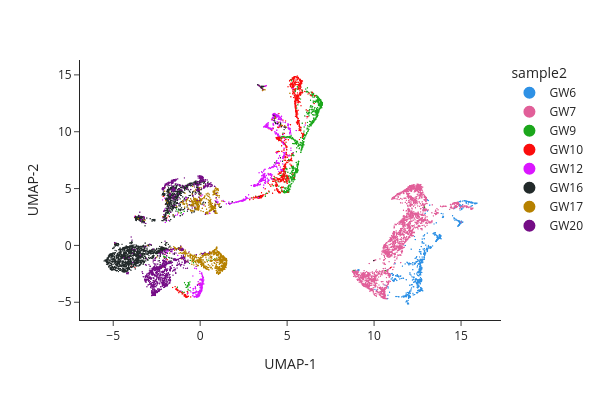

In [12]:
snap.pl.umap(adata, color="sample2", interactive=False)

# Batch correction

In [13]:
%%time
snap.pp.mnc_correct(adata, 
                    batch="sample2")

CPU times: user 10min, sys: 35min 21s, total: 45min 21s
Wall time: 28.2 s


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



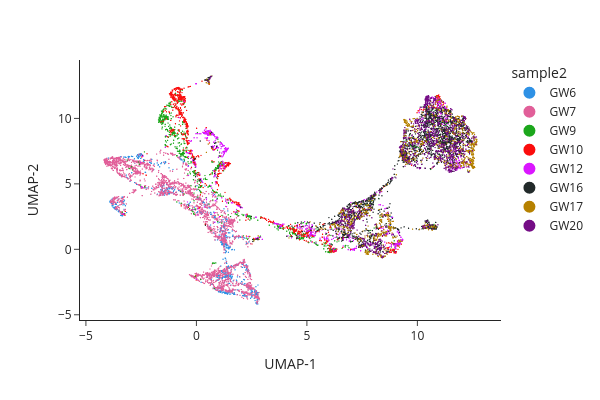

In [14]:
snap.tl.umap(adata, use_rep="X_spectral_mnn")
snap.pl.umap(adata, color="sample2", interactive=False)

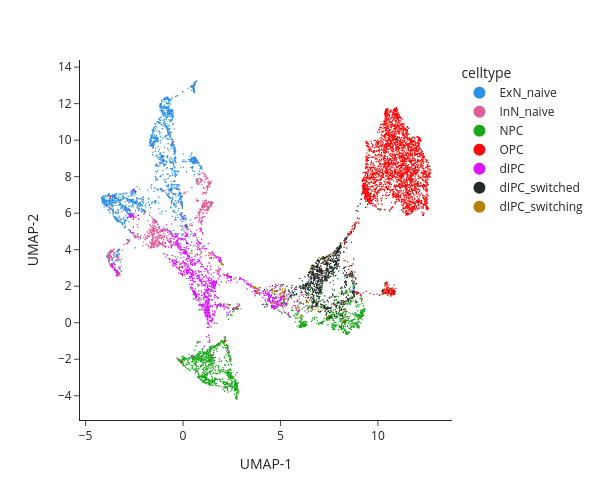

In [15]:
snap.pl.umap(adata, color="celltype", interactive=False, height=500)

In [16]:
adata.obs.to_csv('atac-meta.csv')

## Peak calling

In [17]:
%%time
snap.tl.macs3(adata, groupby='celltype', qvalue=0.01, blacklist='/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hg38-blacklist.v2.bed')

2025-12-23 20:54:34 - INFO - Exporting fragments...
2025-12-23 20:55:28 - INFO - Calling peaks...
100%|██████████| 7/7 [04:41<00:00, 40.20s/it]


CPU times: user 2min 41s, sys: 1min 9s, total: 3min 51s
Wall time: 5min 38s


In [18]:
adata

AnnData object with n_obs × n_vars = 10248 × 606219
    obs: 'sample2', 'barcode2', 'celltype'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'reference_sequences', 'spectral_eigenvalue', 'macs3'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap', 'X_spectral_mnn'

In [19]:
adata.obsm['fragment_paired']

<10248x3088286401 sparse matrix of type '<class 'numpy.uint32'>'
	with 105674899 stored elements in Compressed Sparse Row format>

In [20]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron/neuron.h5ad')

... storing 'sample2' as categorical
... storing 'barcode2' as categorical


In [21]:
adata = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron/neuron.h5ad", backed=None)
adata

AnnData object with n_obs × n_vars = 10248 × 606219
    obs: 'sample2', 'barcode2', 'celltype'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'macs3', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_mnn', 'X_umap', 'fragment_paired'

In [22]:
%%time
peaks = snap.tl.merge_peaks(adata.uns['macs3'], snap.genome.hg38)
peaks.shape

CPU times: user 2.51 s, sys: 948 ms, total: 3.46 s
Wall time: 1.53 s


(162529, 8)

In [23]:
chrom = peaks['Peaks']
chrom.to_pandas().to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron/cCREs.csv', index=False)

In [24]:
%%time
peak_mat = snap.pp.make_peak_matrix(adata, use_rep=peaks['Peaks'])
peak_mat

CPU times: user 3min 21s, sys: 13.2 s, total: 3min 34s
Wall time: 4.95 s


AnnData object with n_obs × n_vars = 10248 × 162529
    obs: 'sample2', 'barcode2', 'celltype'

In [25]:
peak_mat.uns['reference_sequences'] = adata.uns['reference_sequences']
peak_mat.obsm['fragment_paired'] = adata.obsm['fragment_paired']

In [26]:
peak_mat.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron/peak_mat.h5ad')

In [27]:
peak_mat = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Neuron/peak_mat.h5ad", backed=None)

In [28]:
%%time
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='celltype', pvalue=0.05)

CPU times: user 4.62 s, sys: 65.1 ms, total: 4.69 s
Wall time: 4.7 s


In [29]:
marker_peaks

{'ExN_naive': Index(['chr1:904520-905021', 'chr1:916463-916964', 'chr1:940714-941215',
        'chr1:942385-942886', 'chr1:1039216-1039717', 'chr1:1069118-1069619',
        'chr1:1399846-1400347', 'chr1:1420563-1421064', 'chr1:1841483-1841984',
        'chr1:2378329-2378830',
        ...
        'chrX:153794237-153794738', 'chrX:153812217-153812718',
        'chrX:154397990-154398491', 'chrX:154411261-154411762',
        'chrX:154753430-154753931', 'chrX:154892180-154892681',
        'chrY:2935821-2936322', 'chrY:6972376-6972877',
        'chrY:13753523-13754024', 'chrY:15455964-15456465'],
       dtype='object', length=14339),
 'InN_naive': Index(['chr1:944559-945060', 'chr1:1283757-1284258', 'chr1:1787997-1788498',
        'chr1:2139844-2140345', 'chr1:2239600-2240101', 'chr1:2305091-2305592',
        'chr1:2868146-2868647', 'chr1:2883146-2883647', 'chr1:2919788-2920289',
        'chr1:2949948-2950449',
        ...
        'chrX:152999776-153000277', 'chrX:153566051-153566552',
     

2025-12-23 21:00:47 - WARNING - Input contains 61567 peaks, only 50000 peaks will be plotted.


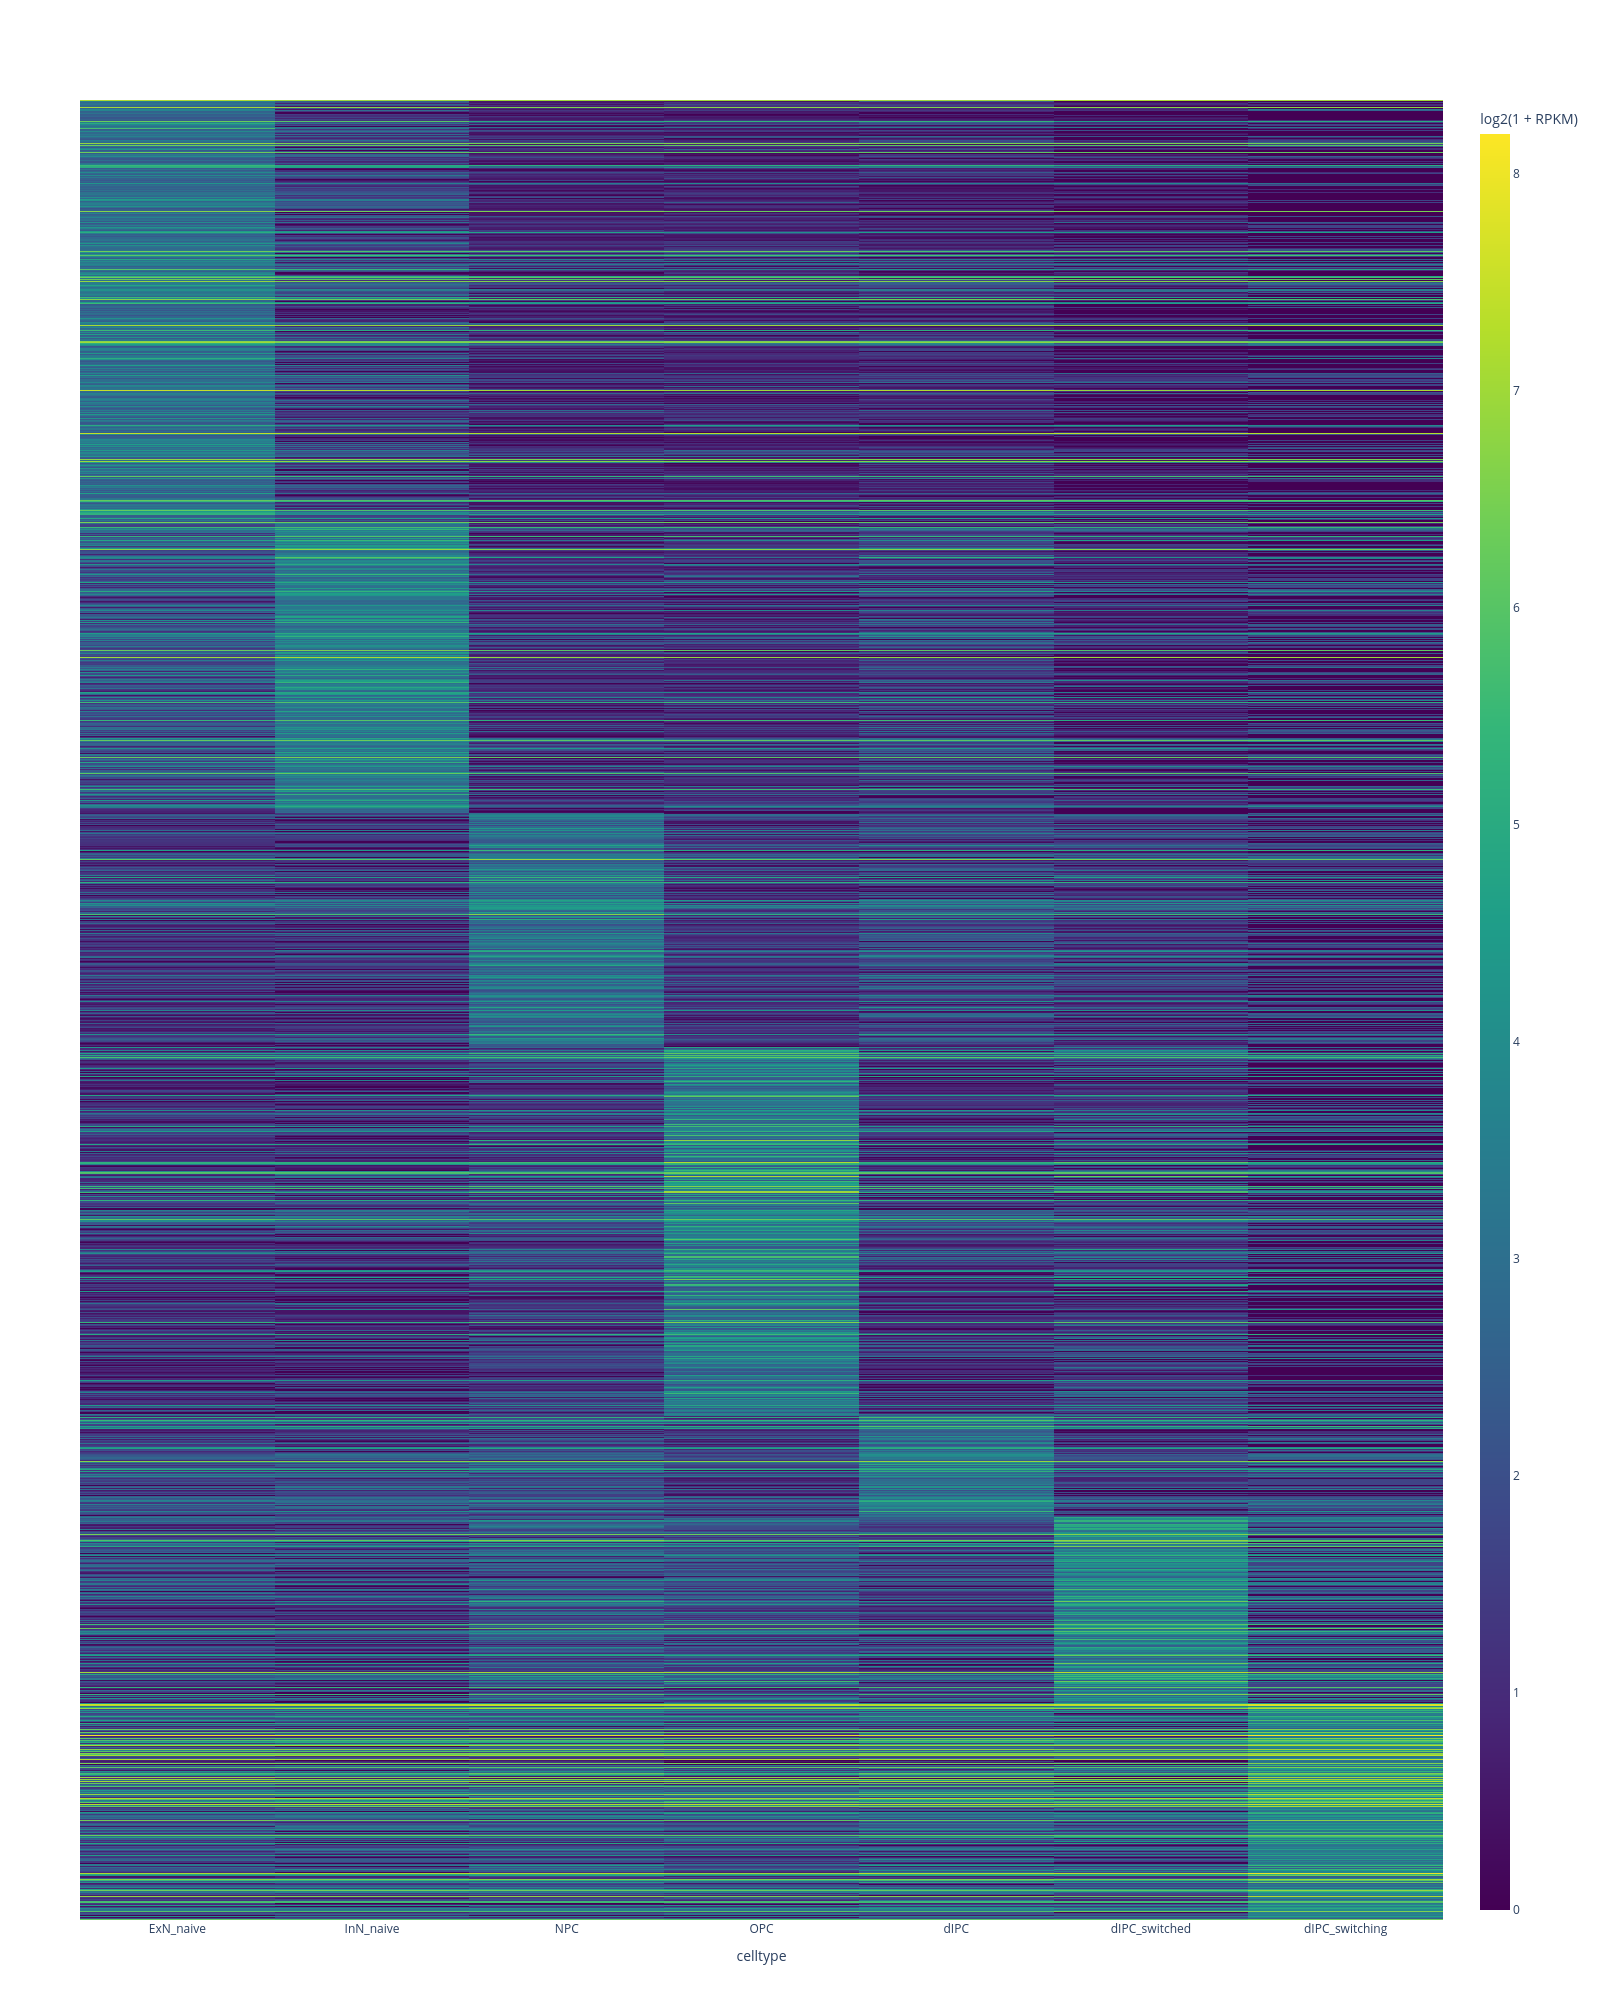

In [30]:
snap.pl.regions(peak_mat, 
                groupby='celltype', 
                peaks=marker_peaks, 
                width = 1600, 
                height = 2000,
                interactive=False)

In [31]:
data = []

# 遍历marker_peaks字典
for cell_type, peaks in marker_peaks.items():
    # 对于每个细胞类型的每个peak，添加到数据列表中
    for peak in peaks:
        data.append([peak, cell_type])

# 创建DataFrame
dar = pd.DataFrame(data, columns=['peak', 'cell_type'])

# 保存为CSV文件
dar.to_csv('neuron_marker_celltype_dar.csv', index=False)